# Jet wake perturbations
this notebook shows the calculation of the jet wake perturbations. The problem is completely described in the section 2.5.2 of Spakovszky PhD thesis.
This version makes use only of functions.py. Another version, using the classes implementation will follow

### import 

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from unsflow.spakovszky.functions import *

### input data

In [2]:
R2 = 1  # initial radius
R3 = 1.5  # outlet radius
Nbl = 20  # number of blades
Q = 0.215  # source term
GAMMA = 0.7032  # circulation term
theta_max = 2 * np.pi / Nbl  # period of the perturbation

### prepare the variables

In [3]:
azimuthal_sampling_points = 100  # number of points along the period
theta = np.linspace(0, theta_max, azimuthal_sampling_points)  # theta domain
theta_deg = theta * 180 / np.pi  # theta domain in degrees
n = Nbl  # interested in the 20th harmonic, since we are looking at perturbation coming from the 20th harmonics
theta0 = theta[0]
omega = -Nbl

### initial conditions

In [4]:
Wr_2 = np.exp(1j * n * theta0)
Wt_2 = np.exp(1j * n * theta0) * (GAMMA - 1) / Q
Wr0 = np.sqrt(1 + ((GAMMA - 1) / Q) ** 2)

### perturbation profiles at different $(\theta,r)$

In [5]:
# specify the radial position where you want to compute the profiles
radii = np.array([R2, 1.05, 1.1, 1.15, 1.2])

swirling flow transfer functions at inlet and outlet

In [6]:
T2 = Trad_n(R2, R2, n, 1j * omega, Q, GAMMA, 0)
T3 = Trad_n(R3, R2, n, 1j * omega, Q, GAMMA, 0)

set up the boundary conditions and the problem

In [7]:
Y = np.zeros((3, 3), dtype=complex)
Y[0, :] = T2[0, :]
Y[1, :] = T2[1, :]
Y[2, :] = T3[2, :]
BC_vec = np.zeros((3, 1), dtype=complex)
BC_vec[0] = np.exp(1j * n * (theta0))
BC_vec[1] = ((GAMMA - 1) / Q) * np.exp(1j * n * (theta0))
BC_vec[2] = 0

find the potential and vortical modes in the system that satisfy the BCs, finding the unknwons of the system

In [8]:
DEN_mode = np.matmul(np.linalg.inv(Y), BC_vec)

plot the profiles at different radius

/opt/anaconda3/envs/unsflow/lib/python3.9/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/unsflow/lib/python3.9/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


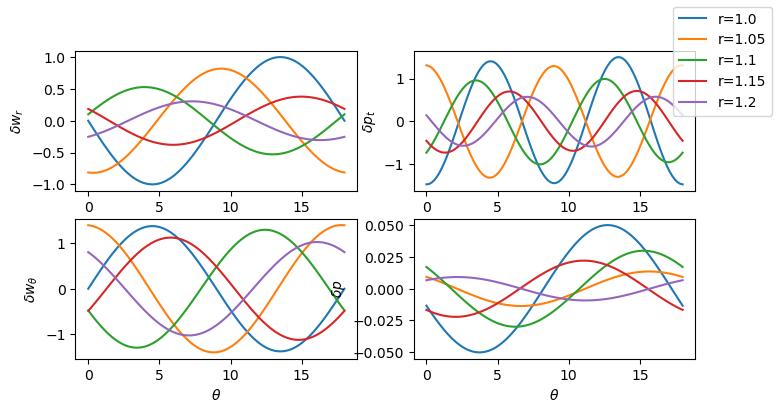

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(8,4))
axes[0, 0].set_ylabel(r'$\delta w_{r}$')
axes[1, 0].set_ylabel(r'$\delta w_{\theta}$')
axes[0, 1].set_ylabel(r'$\delta p_t $')
axes[1, 1].set_ylabel(r'$\delta p $')
axes[1, 0].set_xlabel(r'$\theta $')
axes[1, 1].set_xlabel(r'$\theta $')
r0 = R2
# loop over all the radius specified
for k in range(0, len(radii)):
    radius = radii[k]
    
    # compute now the flow solutions
    vec = np.zeros((3, len(theta)), dtype=complex)
    i = 0
    for t in theta:
        # shift of period/4 in order to match the plots presented in the thesis
        vec[:, i] = np.matmul(Trad_n(radius, r0, n, -1j * n, Q, GAMMA, theta=t + 1 / 4 * theta_max), DEN_mode).reshape(3)
        i = i + 1
    
    axes[0, 0].plot(theta_deg, vec[0, :], label='r=' + str(radius))
    axes[1, 0].plot(theta_deg, vec[1, :])
    axes[1, 1].plot(theta_deg, vec[2, :])
    axes[0, 1].plot(theta_deg, vec[2, :] + 0.5 * (vec[1, :] ** 2 + vec[0, :] ** 2))
    
fig.legend()

### amplitude of the perturbations at different radii
for every radius location, at a certain $\theta$, find the amplitude of the perturbation, and plot the real and imaginary part. 

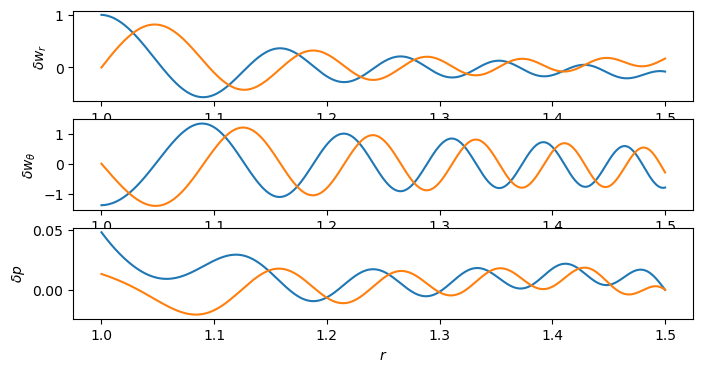

In [14]:
radii = np.linspace(R2, R3, 500)
fig, axes = plt.subplots(3, 1, figsize=(8, 4))
axes[0].set_ylabel(r'$\delta w_{r}$')
axes[1].set_ylabel(r'$\delta w_{\theta}$')
axes[2].set_ylabel(r'$\delta p $')
axes[2].set_xlabel(r'$r $')
vec_rad = np.zeros((3, len(radii)), dtype=complex)
for k in range(0, len(radii)):
    vec_rad[:, k] = np.matmul(Trad_n(radii[k], r0, n, 1j * omega, Q, GAMMA, 0), DEN_mode).reshape(3)
axes[0].plot(radii, vec_rad[0, :].real)
axes[0].plot(radii, vec_rad[0, :].imag)
axes[1].plot(radii, vec_rad[1, :].real)
axes[1].plot(radii, vec_rad[1, :].imag)
axes[2].plot(radii, vec_rad[2, :].real)
axes[2].plot(radii, vec_rad[2, :].imag)

### plot the perturbation phasor
instead of plotting the real and imaginary part, plot directly the phasor trajectory as the radius increase, and check that the boundary condition on the pressure at $R_3$ is respected

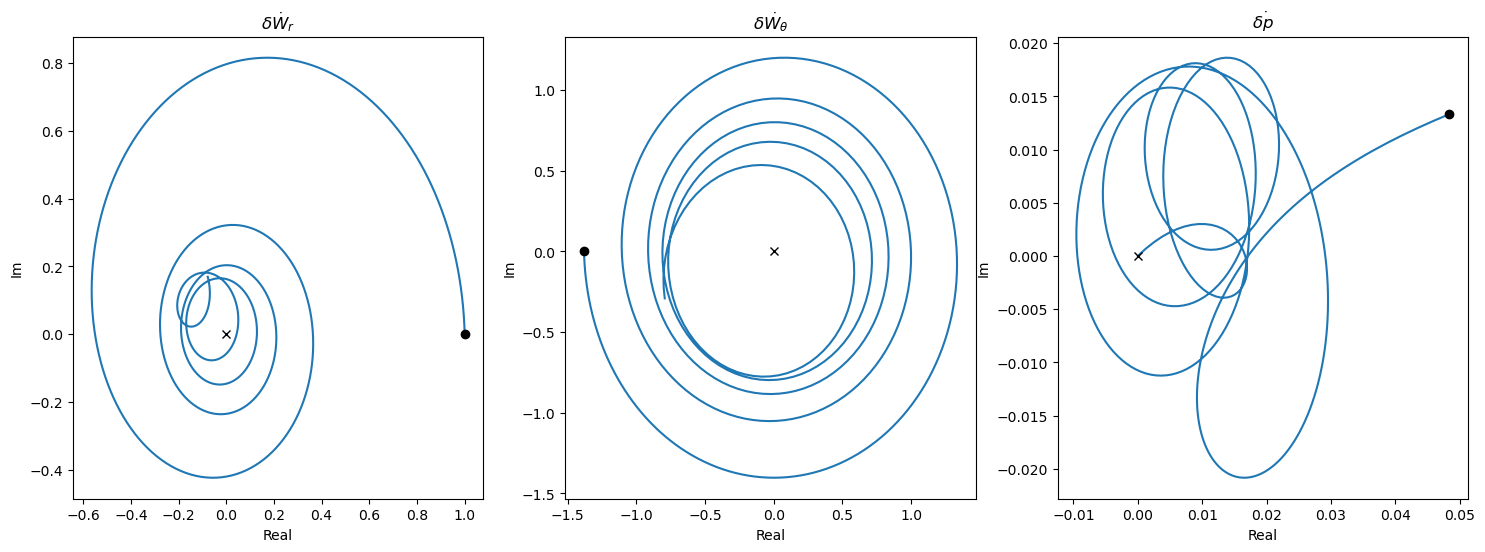

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].set_title(r'$\dot{\delta W_r}$')
axes[0].set_xlabel('Real')
axes[0].set_ylabel('Im')
axes[1].set_title(r'$\dot{\delta W_{\theta}}$')
axes[1].set_xlabel('Real')
axes[1].set_ylabel('Im')
axes[2].set_title(r'$\dot{\delta p}$')
axes[2].set_ylabel('Im')
axes[2].set_xlabel('Real')
axes[0].plot(vec_rad[0, :].real, vec_rad[0, :].imag)
axes[0].plot(vec_rad[0, 0].real, vec_rad[0, 0].imag, 'ko')
axes[0].plot(0, 0, 'kx')
axes[1].plot(vec_rad[1, :].real, vec_rad[1, :].imag)
axes[1].plot(vec_rad[1, 0].real, vec_rad[1, 0].imag, 'ko')
axes[1].plot(0, 0, 'kx')
axes[2].plot(vec_rad[2, :].real, vec_rad[2, :].imag)
axes[2].plot(vec_rad[2, 0].real, vec_rad[2, 0].imag, 'ko')
axes[2].plot(0, 0, 'kx')

### Bode diagrams
at varying $r$, plot the amplitude and phase of the velocity perturbations. 

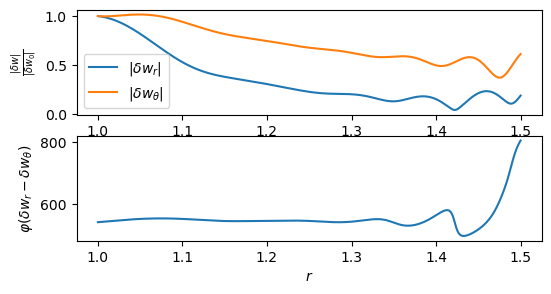

In [16]:
Wr_mag = np.abs(vec_rad[0, :]) / np.abs(vec_rad[0, 0])
Wt_mag = np.abs(vec_rad[1, :]) / np.abs(vec_rad[1, 0])
phase_Wr = np.unwrap(np.angle(vec_rad[0, :])) * 180 / np.pi
phase_Wtheta = np.unwrap(np.angle(vec_rad[1, :])) * 180 / np.pi
delta_phase = -phase_Wr + phase_Wtheta + 360

fig, axes = plt.subplots(2, 1, figsize=(6, 3))
axes[0].set_ylabel(r'$\frac{|\delta w|}{|\delta w_{0}|}$')
axes[1].set_ylabel(r'$\varphi(\delta w_r -\delta w_{\theta} )$')
axes[1].set_xlabel(r'$r $')
axes[0].plot(radii, Wr_mag, label=r'$|\delta w_r|$')
axes[0].plot(radii, Wt_mag, label=r'$|\delta w_{\theta}|$')
axes[1].plot(radii, delta_phase)
axes[0].legend()

### Note
The numerical problems occurring at high radii are due to the radial functions $R_n(r,s)$ used to compute the swirling flow transfer functions, and the other elements as well. When the circumferential mode is large (i.e. here $n=20$), the functions inside the matrices have very big numbers, and the machine floating precision is not enough. 
If you decrease the circumferential mode number, you can see that the problems damp away.
In the thesis, nothing above $R=1.25$ is shown. The following plot shows only that zone

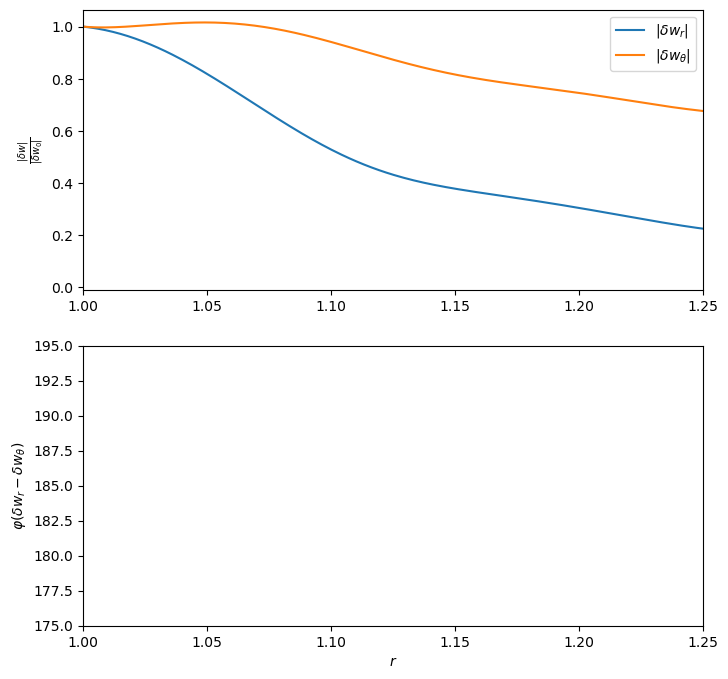

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(8, 8))
axes[0].set_ylabel(r'$\frac{|\delta w|}{|\delta w_{0}|}$')
axes[1].set_ylabel(r'$\varphi(\delta w_r -\delta w_{\theta} )$')
axes[1].set_xlabel(r'$r $')
axes[0].plot(radii, Wr_mag, label=r'$|\delta w_r|$')
axes[0].plot(radii, Wt_mag, label=r'$|\delta w_{\theta}|$')
axes[1].plot(radii, delta_phase)
axes[0].set_xlim([1, 1.25])
axes[1].set_xlim([1, 1.25])
axes[1].set_ylim([175, 195])
axes[0].legend()